In [4]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Loading the dataset, downloaded from Kaggle
#Big Mart Sales Prediction Dataset
df = pd.read_csv("train.csv")

print("First 5 rows of the dataset")
print(df.head())

print("Dataset Information")
print(df.info())

print("Missing Values")
print(df.isnull().sum())
#Item_Weight and Outlet_Size contain missing values, so these columns need preprocessing before training

#Handling the missing values in columns where some entries are unavailable
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)

First 5 rows of the dataset
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999   

/tmp/ipykernel_2054/1177197773.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
/tmp/ipykernel_2054/1177197773.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

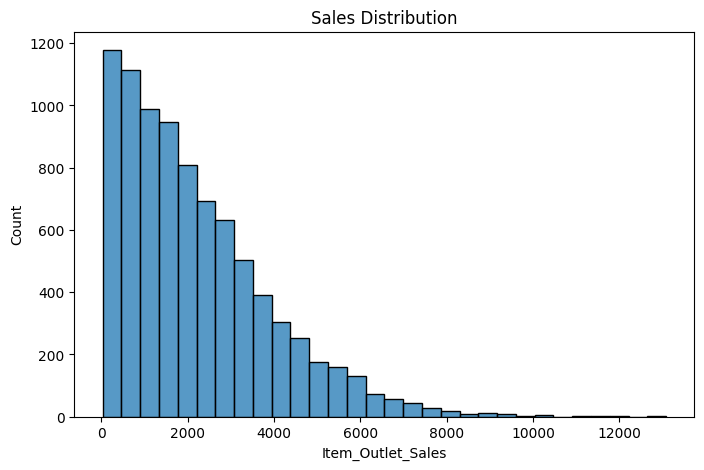

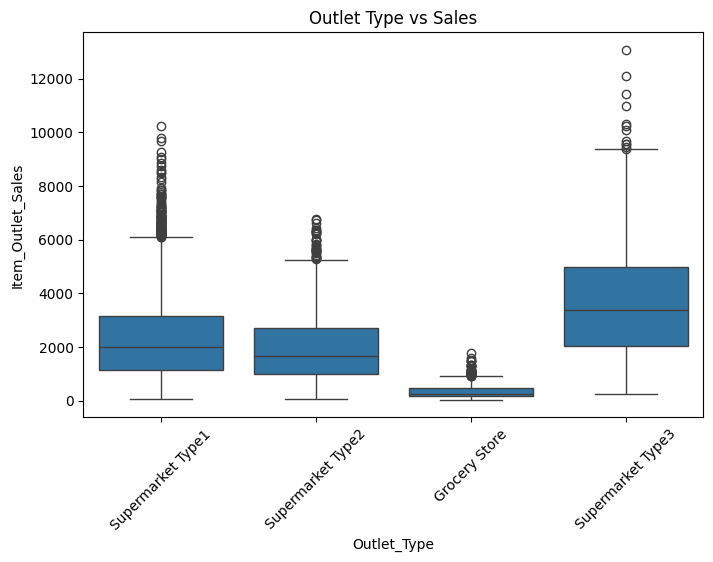

In [6]:
#visualizing the data for better understanding
plt.figure(figsize=(8,5))
sns.histplot(df['Item_Outlet_Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df)
plt.xticks(rotation=45)
plt.title("Outlet Type vs Sales")
plt.show()

In [14]:
#Machine learning models cannot work directly with text data, so categorical columns are converted into numerical values
le = LabelEncoder()

categorical_cols = ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
#Separating features and target variables
X = df.drop(['Item_Outlet_Sales'], axis=1)
y = df['Item_Outlet_Sales']

In [16]:
#Splitting the data into training and testing sets, to evaluate model performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Using Random Forest Regressor because it performs well on tabular datasets
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#making predictions on the test dataset
y_pred = model.predict(X_test)

In [18]:
#Evaluating how well model performs using common regression metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance: ")

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score:", round(r2,4))

Model Performance: 
MAE : 761.99
RMSE : 1092.96
R2 Score: 0.5605


In [11]:
#Comparing actual sales values with the model's predicted values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

print("Actual vs Predicted")
print(results.head(10))

Actual vs Predicted
         Actual    Predicted
7503  1743.0644   751.721490
2957   356.8688   837.569742
7031   377.5086   798.860130
1084  5778.4782  5020.404978
856   2356.9320  2136.885100
4304   865.5400   464.528660
2132  4613.9940  5830.603682
1385  2410.8618  1482.183986
5239  1948.1308  1376.801162
6516  1937.4780  2887.900842


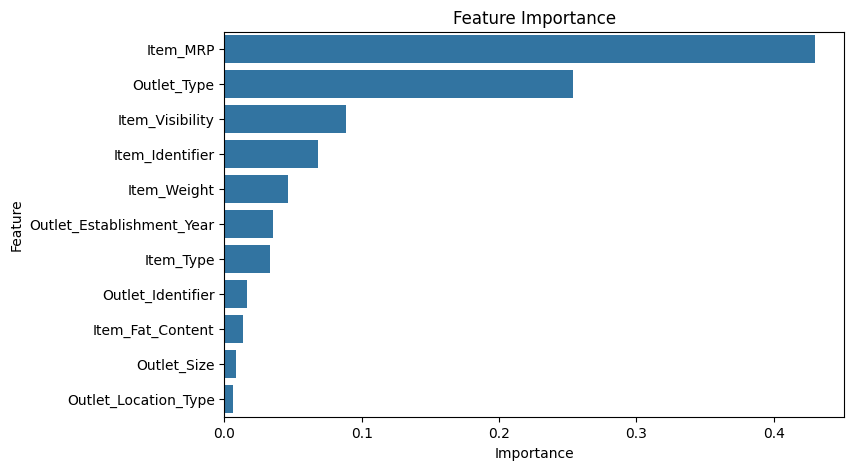

In [12]:
#Checking which features contribute the most to sales prediction
imporance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
imporance = imporance.sort_values(by = 'Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=imporance)
plt.title("Feature Importance")
plt.show()

In [13]:
#Testing the model on a sample product to see predicted sales value
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Sales for Sample Product: ")
print(round(prediction[0],2))

Predicted Sales for Sample Product: 
4202.8
